In [ ]:
!pip install kagglehub

import kagglehub
import os
import glob
import random

# Import dataset
path = kagglehub.dataset_download("puneet6060/intel-image-classification")
print("Dataset path:", path)

train_dir = os.path.join(path, "seg_train", "seg_train")
test_dir = os.path.join(path, "seg_test", "seg_test")

# Task 1 classes
classes_task1 = ['sea', 'forest']
# Task 2 classes
classes_task2 = ['buildings', 'mountain']

random.seed(42)

# Downsample train/test for each class in each task
def downsample_class(class_name, train_dir, test_dir, train_n=500, test_n=250):
    train_files = random.sample(glob.glob(os.path.join(train_dir, class_name, '*.jpg')), train_n)
    test_files = random.sample(glob.glob(os.path.join(test_dir, class_name, '*.jpg')), test_n)
    return train_files, test_files

# Task 1: sea, forest
train_task1, test_task1 = [], []
for i, cname in enumerate(classes_task1):
    files_train, files_test = downsample_class(cname, train_dir, test_dir)
    train_task1 += [(f, i) for f in files_train]
    test_task1  += [(f, i) for f in files_test]

# Task 2: buildings, mountain
train_task2, test_task2 = [], []
for i, cname in enumerate(classes_task2):
    files_train, files_test = downsample_class(cname, train_dir, test_dir)
    train_task2 += [(f, i) for f in files_train]
    test_task2  += [(f, i) for f in files_test]

print("Task 1 train:", len(train_task1))
print("Task 1 test:", len(test_task1))
print("Task 2 train:", len(train_task2))
print("Task 2 test:", len(test_task2))


Using Colab cache for faster access to the 'intel-image-classification' dataset.
Dataset path: /kaggle/input/intel-image-classification
Task 1 train: 1000
Task 1 test: 500
Task 2 train: 1000
Task 2 test: 500


In [ ]:
import cv2
import numpy as np

IMG_SIZE = 150

def preprocess_img_label(img_label_tuples, img_size=IMG_SIZE):
    X, y = [], []
    for img_path, label in img_label_tuples:
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (img_size, img_size))
        img = img / 255.0
        X.append(img)
        y.append(label)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64)

X_train_1, y_train_1 = preprocess_img_label(train_task1)
X_test_1, y_test_1 = preprocess_img_label(test_task1)
X_train_2, y_train_2 = preprocess_img_label(train_task2)
X_test_2, y_test_2 = preprocess_img_label(test_task2)

print("Task 1 train:", X_train_1.shape, y_train_1.shape)
print("Task 1 test:", X_test_1.shape, y_test_1.shape)
print("Task 2 train:", X_train_2.shape, y_train_2.shape)
print("Task 2 test:", X_test_2.shape, y_test_2.shape)


Task 1 train: (1000, 150, 150, 3) (1000,)
Task 1 test: (500, 150, 150, 3) (500,)
Task 2 train: (1000, 150, 150, 3) (1000,)
Task 2 test: (500, 150, 150, 3) (500,)


Task 1 train: (1000, 150, 150, 3) (1000,)
Task 2 train: (1000, 150, 150, 3) (1000,)
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 5, 5, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,718,913 (90.48 MB)

 Trainable params: 14,581,377 (55.62 MB)

 Non-trainable params: 9,137,536 (34.86 MB)

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 40s 313ms/step - accuracy: 0.8883 - loss: 0.3030 - val_accuracy: 0.7580 - val_loss: 0.4708
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.9434 - loss: 0.1495 - val_accuracy: 0.8680 - val_loss: 0.3472
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 62ms/step - accuracy: 0.9483 - loss: 0.1350 - val_accuracy: 0.8600 - val_loss: 0.5616
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.9614 - loss: 0.1190 - val_accuracy: 0.9740 - val_loss: 0.0888
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.9682 - loss: 0.1005 - val_accuracy: 0.9080 - val_loss: 0.3897
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.9619 - loss: 0.1023 - val_accuracy: 0.8280 - val_loss: 0.6936
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.9622 - loss: 0.0943 - val_accuracy: 0.9080 - val_loss: 0.7970
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step - accuracy: 0.9569 - loss: 0.0957 - val_accuracy: 0.6160 -

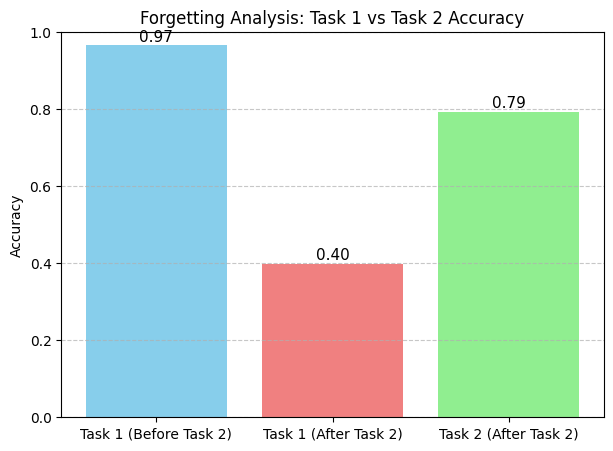

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import cv2, numpy as np, matplotlib.pyplot as plt

# -------------------------------
# Hyperparameters
# -------------------------------
IMG_SIZE = 150
BATCH_SIZE = 16
EPOCHS = 10
LEARNING_RATE = 1e-4
SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)

# -------------------------------
# Load and preprocess functions
# -------------------------------
def preprocess_img_label(img_label_tuples, img_size=IMG_SIZE):
    X, y = [], []
    for img_path, label in img_label_tuples:
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (img_size, img_size))
        img = img / 255.0
        X.append(img)
        y.append(label)
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int64)

# Use your existing train/test data creation here
# (train_task1, test_task1, train_task2, test_task2)
# -----------------------------------------------
X_train_1, y_train_1 = preprocess_img_label(train_task1)
X_test_1,  y_test_1  = preprocess_img_label(test_task1)
X_train_2, y_train_2 = preprocess_img_label(train_task2)
X_test_2,  y_test_2  = preprocess_img_label(test_task2)

print("Task 1 train:", X_train_1.shape, y_train_1.shape)
print("Task 2 train:", X_train_2.shape, y_train_2.shape)

# -------------------------------
# Model Definition
# -------------------------------
base_model = tf.keras.applications.ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Unfreeze last 30 layers to allow forgetting
for layer in base_model.layers[:-30]:
    layer.trainable = False
for layer in base_model.layers[-30:]:
    layer.trainable = True

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),  # new dropout layer
    layers.Dense(1, activation='sigmoid')
])

optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

# -------------------------------
# Train on Task 1 (sea vs forest)
# -------------------------------
history1 = model.fit(
    X_train_1, y_train_1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_1, y_test_1),
    verbose=1
)

# -------------------------------
# Train on Task 2 (buildings vs mountain)
# -------------------------------
history2 = model.fit(
    X_train_2, y_train_2,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_2, y_test_2),
    verbose=1
)

# -------------------------------
# Evaluate performance (Forgetting Check)
# -------------------------------
eval_t1 = model.evaluate(X_test_1, y_test_1, verbose=0)
eval_t2 = model.evaluate(X_test_2, y_test_2, verbose=0)

print(f"Task 1 Accuracy (Before Task 2): {history1.history['val_accuracy'][-1]:.4f}")
print(f"Task 1 Accuracy (After Task 2):  {eval_t1[1]:.4f}")
print(f"Task 2 Accuracy (After Task 2):  {eval_t2[1]:.4f}")

# -------------------------------
# Visualization
# -------------------------------
acc_task1_before = history1.history['val_accuracy'][-1]
acc_task1_after = eval_t1[1]
acc_task2_after = eval_t2[1]

labels = ['Task 1 (Before Task 2)', 'Task 1 (After Task 2)', 'Task 2 (After Task 2)']
values = [acc_task1_before, acc_task1_after, acc_task2_after]

plt.figure(figsize=(7, 5))
bars = plt.bar(labels, values, color=['skyblue', 'lightcoral', 'lightgreen'])
plt.title('Forgetting Analysis: Task 1 vs Task 2 Accuracy')
plt.ylabel('Accuracy')
plt.ylim(0, 1)

for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.2f}", ha='center', fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


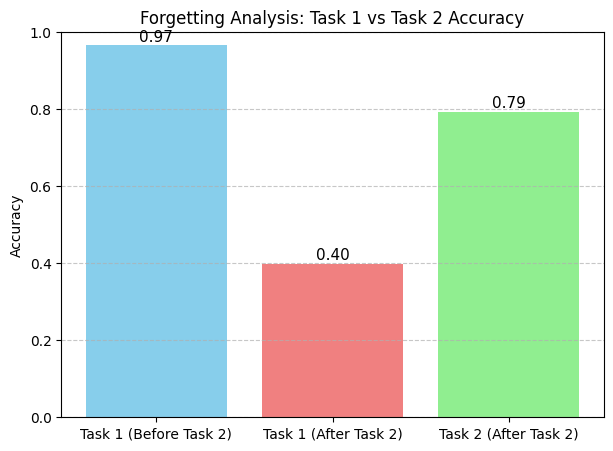

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ---- Accuracy values ----
# Task 1 accuracy after first training (from history1)
acc_task1_before = history1.history['val_accuracy'][-1]  # last epoch validation accuracy
# Task 1 accuracy after retraining on Task 2 (already evaluated)
acc_task1_after = eval_t1[1]  # from model.evaluate
# Task 2 accuracy after Task 2 training
acc_task2_after = eval_t2[1]

# ---- Bar chart ----
labels = ['Task 1 (Before Task 2)', 'Task 1 (After Task 2)', 'Task 2 (After Task 2)']
values = [acc_task1_before, acc_task1_after, acc_task2_after]

plt.figure(figsize=(7, 5))
bars = plt.bar(labels, values, color=['skyblue', 'lightcoral', 'lightgreen'])
plt.title('Forgetting Analysis: Task 1 vs Task 2 Accuracy')
plt.ylabel('Accuracy')
plt.ylim(0, 1)

# Annotate bars with accuracy values
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.2f}", ha='center', fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
